# USDA Cat Detection List

Includes all cats (domestic and wild)

* Put together table of all cat outbreaks/detections recorded by USDA as of current date (7/25/2025)
* Cross reference date, state, and host to find genotype from our datasets

In [1]:
# Housekeeping

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
from matplotlib import pyplot
import dateutil 
from datetime import datetime, timedelta
import plotly.graph_objects as go
import importlib
import utils  
importlib.reload(utils)
from utils import * 

# home = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu/"
# downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
home = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu/"
downloads = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/" 
# originals = downloads + "Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--10-03-2025_Antarctica_North_America_South_America/"
originals = downloads + "Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/"
# new_B3_13 = downloads + "Combinations/GISAID_Andersen_NCBI_Virus/11-01-2021--06-05-2025_B3_13/"
# new_D1_1 = downloads + "Combinations/GISAID_Andersen_NCBI_Virus/11-01-2021--06-05-2025_D1_1/"
cat_files = downloads + "Cats/"

os.chdir(home + "references/")
animals_ref = pd.read_csv("animals_ref.csv")
states_ref = pd.read_csv("states_ref.csv")

os.chdir(cat_files + "USDA/")
detections = pd.read_csv("HPAI Detections in Mammals_8_5_2025.csv") # Does not go past 9/24/2025, however


In [2]:
print(animals_ref["feline"])

display(detections)

0                cat
1       domestic_cat
2          feral_cat
3             feline
4       domestic-cat
            ...     
1035             NaN
1036             NaN
1037             NaN
1038             NaN
1039             NaN
Name: feline, Length: 1040, dtype: object


,State,County,Date Collected,Date Detected,HPAI Strain,Species
0,Massachusetts,Suffolk,2/13/2025,7/8/2025,EA H5,Harbor seal
1,Texas,Ochiltree,2/22/2025,7/8/2025,EA H5,Skunk (unidentified)
2,Texas,Randall,2/24/2025,7/8/2025,EA/AM H5N1,Skunk (unidentified)
3,Texas,Ochiltree,2/24/2025,7/8/2025,EA/AM H5N1,Skunk (unidentified)
4,Texas,Randall,3/13/2025,7/8/2025,EA/AM H5N1,Skunk (unidentified)
...,...,...,...,...,...,...
638,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
639,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
640,Wisconsin,Dane,5/5/2022,5/6/2022,EA H5N1,Red fox
641,Wisconsin,Rock,4/19/2022,5/5/2022,EA H5N1,Red fox


In [3]:
# Find only cats

detections["Species"] = detections["Species"].apply(str.lower)
detections["Feline"] = detections["Species"].apply(lambda x: "feline" if x in animals_ref["feline"].values else "non-feline")
detections_feline = detections[detections["Feline"] == "feline"]

print(detections_feline["Date Detected"].apply(lambda x: dateutil.parser.parse(x)).sort_values())

# Export as csv
detections_feline.to_csv("USDA_feline_detections_10_03_2025.csv")

detections_feline_unique = detections_feline.drop_duplicates(keep="first")
# detections_feline_unique.to_csv("USDA_feline_detections_unique_06_03_2025.csv")

613   2022-05-24
612   2022-05-24
558   2022-09-27
531   2022-12-23
529   2023-01-03
         ...    
26    2025-05-08
24    2025-05-15
18    2025-06-16
12    2025-07-03
9     2025-07-08
Name: Date Detected, Length: 214, dtype: datetime64[ns]


## Find genotypes with feline from datasets

In [4]:
# Prepare dataframes 

# def fasta_df_og(file_name, state_ref):

#     fasta = pd.DataFrame()
#     headers = []
#     isolate_ids = []
#     isolate_names = []
#     subtypes = []
#     segments = []
#     collection_dates = []
#     sequences = []
#     host_types = []
#     species = []
#     genotypes = []
#     with open(file_name) as f:
#         lines = f.readlines()
#         for num, line in enumerate(lines):
#             # print(line)
#             if line[0] == ">": # If it's a header
#                 if line[1:].strip() not in headers: # And the previous line is not a header we've seen before
                    
#                     header = line[1:].strip() # Remove the ">"
#                     # print(header)
#                     if len(header.split("|")) > 6:
#                         header = header.replace(header.split("|")[0], "")[1:]
#                     split_header = header.split("|")
#                     split_first_header = split_header[0].split("/")
#                     # print(split_first_header)
#                     headers.append(header) 
#                     isolate_ids.append(split_first_header[3])
#                     isolate_names.append(split_header[1]) # We'll need to extract data from this too
#                     # print(split_header[2].split("_")[-1])
#                     subtypes.append(split_header[-4])  # Get only H5N1
#                     genotypes.append(split_header[-1])
#                     segments.append(file_name.split("_")[-3])
#                     host_types.append(split_header[-2])
#                     species.append(split_first_header[1])
#                     # if split_header[4] == "2024-01-01":
#                     #     collection_dates.append("2024") # No samples were collected 1/1/2024, these are all unknown 
#                     # elif split_header[4] == "2025-01-01":
#                     #     collection_dates.append("2025")
#                     # else: 
#                     collection_dates.append(split_header[-3].split("_")[-1])
#                     if num < len(lines): # If we're not at the last line
#                         # for i, l in enumerate(lines[num + 1:]):
#                         i = num
#                         sequence = ""
#                         # print(lines[i])
#                         # print(lines[i + 1])
#                         while i < len(lines) - 1 and lines[i + 1][0] != ">": # While the next line is part of a sequence
#                             sequence = sequence + lines[i + 1].strip()
#                             i += 1
#                         sequences.append(sequence) # Add next line to sequences
#         f.close()

#     # Create columns for data frame 
#     fasta["Header"] = headers
#     fasta["Isolate_Id"] = isolate_ids
#     fasta["Isolate_Name"] = isolate_names
#     fasta["Subtype"] = subtypes
#     fasta["Segment"] = segments
#     # Geo_Location is more complicated
#     fasta["Geo_Location"] = fasta["Header"].apply(lambda x: state_ref.loc[state_ref["Abbreviation"] == x.split("/")[2], 'Country'].iloc[0] + "-" + x.split("/")[2] if x.split("/")[2] in state_ref["Abbreviation"].values else state_ref.loc[state_ref["State"] == x.split("/")[2].replace("_", " "), 'Country'].iloc[0] + "-" + state_ref.loc[state_ref["State"] == x.split("/")[2].replace("_", " "), 'Abbreviation'].iloc[0] if x.split("/")[2].replace("_", " ") in state_ref["State"].values else x.split("/")[2].replace(": ", "-"))
#     fasta["Date Collected"] = collection_dates
#     fasta["Species"] = species
#     fasta["Host_Type"] = host_types
#     fasta["Genotype"] = genotypes
#     fasta["Sequence"] = sequences
    
#     return fasta

# Grab files

os.chdir(originals)
cat_genotypes = set()
dfs = {}
for dirpath, dirs, files in os.walk(originals):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if "PB2" in file_name and ".fasta" in file_name: # All metadata should be same
            with open(file_name) as f:
                lines = f.readlines()
                for line in lines:
                    if "feline" in line:
                        print(file_name)
                        cat_genotypes.add(line.split("|")[-1]) # The genotype
                        # print(line)
                        # break 
                        # if len(line.split("|")) > 6:
                        #     line = line.replace(line.split("|")[0])[1:]
                        #     dfs[file_name] = fasta_df_og(file_name, states_ref)
                        # else:
                        dfs[file_name] = fasta_df_complete(file_name, states_ref)
                        break 

print(cat_genotypes)

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/all_A3_PB2_combined_11-01-2021--07-25-2025.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/all_B3.13_PB2_combined_11-01-2021--07-25-2025.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/all_B3.2_PB2_combined_11-01-2021--07-25-2025.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/all_B3.5_PB2_combined_11-01-2021--07-25-2025.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/all_B3.6_PB2_comb

### Cross-reference USDA cat list with our dataset to find genotypes

Append genotypes to USDA cat list

In [5]:
# print(dfs["C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\D1.1_PB2_combined_04-14-2025.fasta"])

os.chdir(cat_files)

# Get cats only
cat_dfs = {}
for key in dfs.keys():
    df_value = dfs[key]
    cat_df = df_value[df_value["Host_Type"] == "feline"]
    cat_dfs[key] = cat_df
    # file_name = key[:-6].split("/")[-1].split("_")[1] + "_cat_df.csv"
    # cat_df.to_csv(file_name)


In [6]:
# Get same geolocation for detections_feline

detections_feline["Geo_Location"] = detections_feline["State"].apply(lambda x: 
                                                # If "x" has the state abbreviation (e.g. "MD")
                                                states_ref.loc[states_ref["Abbreviation"].str.contains('|'.join(x.replace(": ", ",").replace(" ", "_").split(',')), regex=True), 'Country'].iloc[0] 
                                                + "-" + 
                                                x.split(" ")[-1]
                                                if states_ref["Abbreviation"].str.contains("|".join((x.replace(": ", ",").replace(" ", "_").split(','))), regex=True).any()
                                                # If "x" has the full state name (e.g. "Maryland")
                                                else states_ref.loc[states_ref['State'].str.contains('|'.join(x.replace(": ", ",").replace(" ", "_").split(',')), regex=True), 'Country'].iloc[0]
                                                + "-" + 
                                                states_ref.loc[states_ref['State'].str.contains('|'.join(x.replace(": ", ",").replace(" ", "_").split(',')), regex=True), 'Abbreviation'].iloc[0] 
                                                if states_ref["State"].str.contains("|".join((x.replace(": ", ",").replace(" ", "_").split(','))), regex=True).any()
                                                # If "x" has neither the state abbreviation nor the full state name nor is "USA"
                                                else 
                                                x
                                                )
detections_feline["Identifier"] = detections_feline.index

print(detections_feline)


# detections_feline_unique["Geo_Location"] = detections_feline_unique["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)

# print(detections_feline_unique)

            State     County Date Collected Date Detected HPAI Strain  \
9          Oregon  Multnomah       7/1/2025      7/8/2025     EA H5N1   
12     New Jersey     Mercer      6/30/2025      7/3/2025       EA H5   
18     California    Alameda     12/11/2024     6/16/2025       EA H5   
24   South Dakota     Aurora       5/6/2025     5/15/2025  EA/AM H5N1   
26         Kansas     Kearny      1/30/2025      5/8/2025  EA/AM H5N1   
..            ...        ...            ...           ...         ...   
530        Oregon       Linn     12/27/2022      1/3/2023  EA/AM H5N1   
531        Oregon       Linn     12/19/2022    12/23/2022  EA/AM H5N1   
558      New York    Albany1      9/17/2022     9/27/2022     EA H5N1   
612     Wisconsin    Lincoln      4/24/2022     5/24/2022     EA H5N1   
613     Wisconsin    Lincoln       5/5/2022     5/24/2022     EA H5N1   

          Species  Feline Geo_Location  Identifier  
9    domestic cat  feline       USA-OR           9  
12   domestic cat

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\1721773643.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Geo_Location"] = detections_feline["State"].apply(lambda x:
C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\1721773643.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Identifier"] = detections_feline.index


### If geo_location and species match, add list of possible genotypes to USDA


In [7]:
# Find genotypes matching USDA

matches = {}
for key in cat_dfs.keys():
    df = cat_dfs[key]
    # concat_df = pd.concat([detections_feline, df], ignore_index=True) # concatenate the dfs
    # no_dupes_df = concat_df.drop_duplicates(subset=["State", "Date Collected", "Species"])
    # combined_df = pd.merge(detections_feline_unique, df, on=["Geo_Location"])
    combined_df = pd.merge(detections_feline, df, on=["Geo_Location"], how="left")
    combined_df["Genotype"] = combined_df["Genotype"].apply(lambda x: "No match" if x != x else x)

    matches[key] = combined_df
    # print(combined_df)

matches_exist = {}
for key in matches.keys():
    # If dataframe not empty, show it 
    if len(matches[key]) > 0:
        matches_exist[key] = matches[key]
        # print(matches[key])

print(matches_exist)

for key in matches_exist:
    df = matches_exist[key]
    file_name = key[:-6].split("/")[-1].split("_")[1]
    # df.to_csv(file_name + "_matches.csv")

{'C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/Andersen_NCBI_Virus_GISAID/11-01-2021--07-25-2025_Antarctica_North_America_South_America/all_A3_PB2_combined_11-01-2021--07-25-2025.fasta':             State     County Date Collected_x Date Detected HPAI Strain  \
0          Oregon  Multnomah         7/1/2025      7/8/2025     EA H5N1   
1      New Jersey     Mercer        6/30/2025      7/3/2025       EA H5   
2      California    Alameda       12/11/2024     6/16/2025       EA H5   
3    South Dakota     Aurora         5/6/2025     5/15/2025  EA/AM H5N1   
4          Kansas     Kearny        1/30/2025      5/8/2025  EA/AM H5N1   
..            ...        ...              ...           ...         ...   
209        Oregon       Linn       12/27/2022      1/3/2023  EA/AM H5N1   
210        Oregon       Linn       12/19/2022    12/23/2022  EA/AM H5N1   
211      New York    Albany1        9/17/2022     9/27/2022     EA H5N1   
212     Wisconsin    Lincoln        4/24/

In [8]:
# Make list of possible genotypes per USDA row 

# Concatenate all matches_exist dataframes and drop duplicates on the columns

big_df = pd.DataFrame()
for key in matches_exist.keys():
    df = matches[key]
    big_df = pd.concat([big_df, df], ignore_index=True)



# big_df_dupes = big_df[big_df.duplicated(subset=["Geo_Location", "Species", "Genotype"], keep=False)]

# print(big_df)

# big_df_no_seg = big_df.drop(columns=["Segment", "Sequence"])

# big_df = big_df.drop_duplicates(subset=["Isolate_Id", "Genotype"], keep="last", ignore_index=True)

big_df["Date Collected_x"] = big_df["Date Collected_x"].apply(lambda x: dateutil.parser.parse(x) if x == x else x) # if x != "2024" and x != "2025" else x) #.strftime("%Y-%m-%d"))
big_df["Date Detected"] = big_df["Date Detected"].apply(lambda x: dateutil.parser.parse(x)  if x == x else x) # if x != "2024" and x != "2025" else x) #.strftime("%Y-%m-%d"))
big_df["Date Collected_y"] = big_df["Date Collected_y"].apply(lambda x: dateutil.parser.parse(x)  if x == x else x) # if x not in ["2021", "2022", "2023", "2024", "2025"] else x) #.strftime("%Y-%m-%d"))

print(big_df) # [big_df["Date Collected_y"] == "2025"])

# subset=["Date Collected_x", "Geo_Location", "Species", "Genotype"]
# big_df = big_df.drop_duplicates(subset=["Isolate_Id", "Genotype"], keep='last', ignore_index=True)

# print(big_df_dupes)

# print(big_df)

             State     County Date Collected_x Date Detected HPAI Strain  \
0           Oregon  Multnomah       2025-07-01    2025-07-08     EA H5N1   
1       New Jersey     Mercer       2025-06-30    2025-07-03       EA H5   
2       California    Alameda       2024-12-11    2025-06-16       EA H5   
3     South Dakota     Aurora       2025-05-06    2025-05-15  EA/AM H5N1   
4           Kansas     Kearny       2025-01-30    2025-05-08  EA/AM H5N1   
...            ...        ...              ...           ...         ...   
4328        Oregon       Linn       2022-12-27    2023-01-03  EA/AM H5N1   
4329        Oregon       Linn       2022-12-19    2022-12-23  EA/AM H5N1   
4330      New York    Albany1       2022-09-17    2022-09-27     EA H5N1   
4331     Wisconsin    Lincoln       2022-04-24    2022-05-24     EA H5N1   
4332     Wisconsin    Lincoln       2022-05-05    2022-05-24     EA H5N1   

         Species_x  Feline Geo_Location  Identifier_x Header  ...  \
0     domestic cat

In [9]:
# Make sure dates correspond by checking if:
# Date Collected_y is between Date Collected_x and Date Detected
# OR 
# Date Collected_y, if year only, corresponds to either Date Collected_x year or Date Detected year

big_df["Date_Match_Beg"] = big_df["Date Collected_y"] - big_df["Date Collected_x"]
big_df["Date_Match_Beg"] = big_df["Date_Match_Beg"].apply(lambda x: 1 if x >= timedelta(days = 0) else 0)

big_df["Date_Match_End"] = big_df["Date Detected"] - big_df["Date Collected_y"]
big_df["Date_Match_End"] = big_df["Date_Match_End"].apply(lambda x: 1 if x >= timedelta(days = 0) else 0)

big_df["Date_Match_Sum"] = big_df["Date_Match_Beg"] + big_df["Date_Match_End"]

big_df = big_df[big_df["Date_Match_Sum"] > 1]
# big_df = big_df[big_df["Date Collected_x"] == big_df["Date Collected_y"]]
# big_df["Header"] = big_df["Header"].apply(lambda x: x.replace(x.split("|")[0], "")[1:])
# big_df = big_df[big_df["Date_Match_Beg"] > 0]

print(big_df)

           State    County Date Collected_x Date Detected HPAI Strain  \
103    Minnesota  Morrison       2024-12-06    2024-12-18     EA H5N1   
242   California   Alameda       2024-12-11    2025-06-16       EA H5   
243   California   Alameda       2024-12-11    2025-06-16       EA H5   
244   California   Alameda       2024-12-11    2025-06-16       EA H5   
245   California   Alameda       2024-12-11    2025-06-16       EA H5   
...          ...       ...              ...           ...         ...   
4184    Colorado   Denver1       2024-12-18    2024-12-23     EA H5N1   
4189   Minnesota  Morrison       2024-12-06    2024-12-18     EA H5N1   
4205     Arizona  Maricopa       2024-12-05    2024-12-12  EA/AM H5N1   
4206     Arizona  Maricopa       2024-12-05    2024-12-12  EA/AM H5N1   
4207       Idaho      Ada1       2024-11-19    2024-12-10  EA/AM H5N1   

                    Species_x  Feline Geo_Location  Identifier_x  \
103              domestic cat  feline       USA-MN     

In [10]:
os.chdir(cat_files)

# big_df.to_csv("Possible_Genotypes_USDA_Feline_Unique_Isolates.csv", index=None)

# big_df.to_csv("Possible_Genotypes_USDA_Feline_10_03_2025_ambig_dates.csv", index=None)

big_df.to_csv("Possible_Genotypes_USDA_Feline_7_25_2025_ambig_dates.csv", index=None)

## Plots

          State      County Date Collected Date Detected HPAI Strain  \
0        Oregon   Multnomah     2025-07-01      7/8/2025     EA H5N1   
1    California     Alameda     2024-12-11     6/16/2025       EA H5   
2        Kansas      Kearny     2025-01-30      5/8/2025  EA/AM H5N1   
3    California       Modoc     2025-04-13      5/7/2025       EA H5   
4         Idaho         Ada     2025-04-15     4/29/2025       EA H5   
..          ...         ...            ...           ...         ...   
176    Nebraska  Lancaster1     2022-12-21      1/3/2023  EA/AM H5N1   
177      Oregon        Linn     2022-12-27      1/3/2023  EA/AM H5N1   
178      Oregon        Linn     2022-12-19    12/23/2022  EA/AM H5N1   
179   Wisconsin     Lincoln     2022-04-24     5/24/2022     EA H5N1   
180   Wisconsin     Lincoln     2022-05-05     5/24/2022     EA H5N1   

                     Species  Feline Geo_Location  Identifier  Month  Year  \
0               domestic cat  feline       USA-OR        

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\2714187299.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Date Collected"] = pd.to_datetime(detections_feline["Date Collected"].apply(dateutil.parser.parse), format="%Y-%m-%d") # .apply(lambda x: dateutil.parser.parse(x).strftime("%Y-%m-%d"))
C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\2714187299.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Month"] = detections_feline["Date

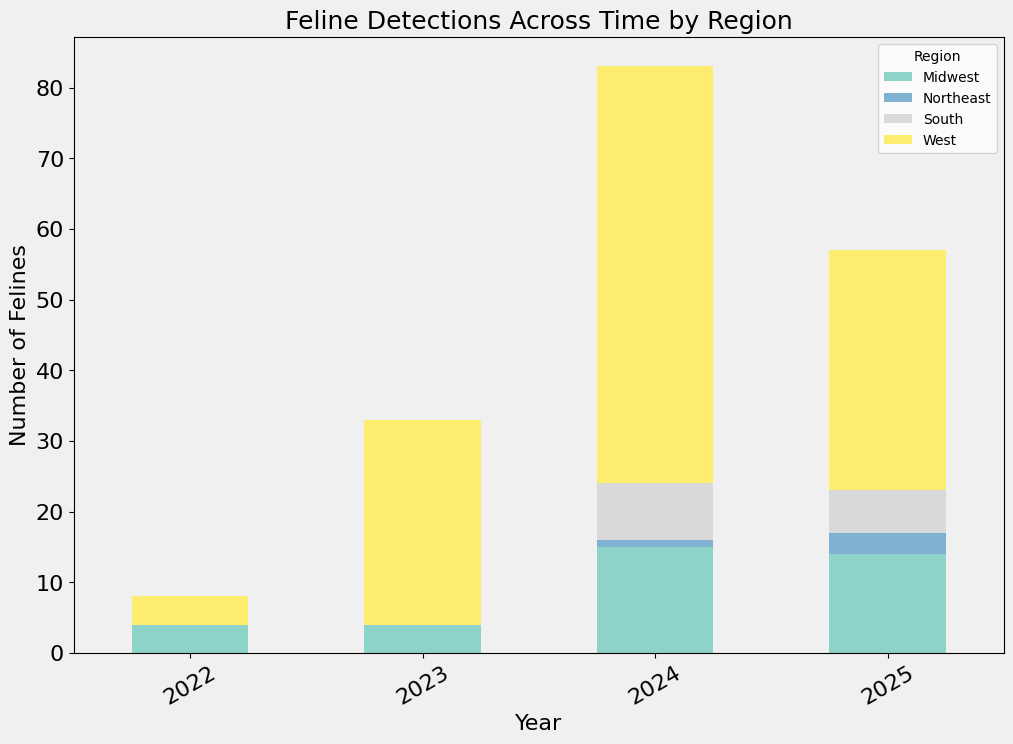

In [11]:
# Plot detections through time -- group by month/week 

detections_feline["Date Collected"] = pd.to_datetime(detections_feline["Date Collected"].apply(dateutil.parser.parse), format="%Y-%m-%d") # .apply(lambda x: dateutil.parser.parse(x).strftime("%Y-%m-%d"))
detections_feline["Month"] = detections_feline["Date Collected"].apply(lambda x: x.month)
detections_feline["Year"] = detections_feline["Date Collected"].apply(lambda x: x.year)
detections_feline["Month_Year"] =  detections_feline["Year"].apply(lambda x: str(x)) + "-" + detections_feline["Month"].apply(lambda x: str(x)) 
detections_feline["Month and Year"] = pd.to_datetime(detections_feline["Month_Year"].apply(dateutil.parser.parse), format="%Y-%m")
detections_feline = detections_feline.merge(states_ref, on="State")
print(detections_feline)
detections_feline_count = detections_feline.groupby(by=["Feline", "Region", "Year"], as_index=False).count().sort_index(ascending=True)

print(detections_feline_count)

detections_feline_count_trimmed = detections_feline_count[["Year", "State", "Region"]]

print(detections_feline_count_trimmed)

# fig, ax = pyplot.subplots(1, 1, figsize=(10, 10))

# index = pd.date_range(start=detections_feline["Date Collected"].min(), end=detections_feline["Date Collected"].max(), freq="3M", name="date")
# # data = np.random.randn(100, 4).cumsum(axis=0)
# # wide_df = pd.DataFrame(data, index, ["a", "b", "c", "d"])
# print(index)

# index_str = []
# for x in list(index):
#     index_str.append(str(x).replace("-", "/"))

# diff = (pd.to_datetime(index, format='%Y-%m-%d') - pd.to_datetime('1990-1-1', format='%Y-%m-%d')).total_seconds()
# s = pd.to_timedelta(pd.to_datetime(detections_feline["Date Collected"]).dt.time.astype(str))
# detections_feline_count['time'] = pd.cut(s, bins=pd.to_timedelta(diff))

detections_feline_count_trimmed = pd.pivot_table(detections_feline_count_trimmed, index="Year", values="State", columns="Region", aggfunc="sum", fill_value=0)

print(detections_feline_count_trimmed)
print(detections_feline_count_trimmed.sum())

fig, ax = pyplot.subplots(figsize=(12, 8))
# sns.scatterplot(data = detections_feline_count, x="Date Collected", y="Feline", hue="Region")
detections_feline_count_trimmed.plot(ax=ax, kind="bar", stacked=True,  colormap="Set3", fontsize=16)
ax.set_title("Feline Detections Across Time by Region", fontsize=18)
ax.set_ylabel("Number of Felines", fontsize=16)
ax.set_xlabel("Year", fontsize=16)
# ax.set_xlabel("Month and Year")
ax.tick_params(axis='x', labelrotation=30)
ax.set_facecolor("#f0f0f0")
fig.patch.set_facecolor("#f0f0f0")

# ax.set_title("Feline Detections Across Time by Region")
# fig.savefig("feline_counts_region_bar_year_07-25-2025.png")
# ax.set_xticks(range(len(list(index))))
# ax.set_xticklabels(list(index), rotation=30)
# break 
# sns.scatterplot(data=wide_df)



In [12]:
# # Plot detections (ONLY from USDA) as a stacked bar chart where:
# # Each bar is a state
# # Each plot is a different domestication status of cat (wild/big vs. domesticated cats)



# detections_feline["Domestication"] = detections_feline["Species"].apply(lambda x: "domestic" if x == "domestic cat" or x == "cat" else "wild")

# detections_feline_trimmed = detections_feline[["State", "Species", "Domestication", "Region"]]

# print(detections_feline_trimmed)

# detections_domesticated = detections_feline_trimmed[detections_feline_trimmed["Domestication"] == "domestic"]
# print(len(detections_domesticated))
# detections_domesticated_trimmed = detections_domesticated[["State", "Species"]].groupby(["State"]).count().rename(columns={"Species":"Domestic Cat"})
# detections_wild = detections_feline_trimmed[detections_feline_trimmed["Domestication"] == "wild"]
# detections_wild_trimmed = pd.pivot_table(detections_wild, index="State", values="Domestication", columns="Species", aggfunc="count", fill_value=0) # .groupby(["State", "Species"]).size()

# print(detections_domesticated_trimmed)
# # break 
# # print(detections_wild_trimmed)

# # fig, axes = pyplot.subplots(1, 2)


# regions = list(set(detections_domesticated["Region"].values))

# sub_categories = []
# for region in regions:
#     sub_categories.append(list(set(detections_domesticated[detections_domesticated["Region"] == region]["State"].values)))

# grouped_data = detections_domesticated.groupby("Region")

# # display(grouped_data)

# fig, ax = pyplot.subplots(1, 1, figsize=(16, 12))

# # fig.suptitle('Domestic Cat Infection Count Grouped by US Region', fontsize=16, y=0.92)

# # Sample data
# # categories = ['Category A', 'Category B', 'Category C']
# # sub_categories = ['Sub1', 'Sub2', 'Sub3']
# # data = {
# #     'Category A': {'Sub1': 10, 'Sub2': 15, 'Sub3': 8},
# #     'Category B': {'Sub1': 12, 'Sub2': 9, 'Sub3': 18},
# #     'Category C': {'Sub1': 7, 'Sub2': 20, 'Sub3': 11}
# # }

# # Parameters
# num_categories = len(regions)
# num_sub_categories = 0 
# for category in sub_categories:
#     for state in category:
#         num_sub_categories += 1
# bar_width = 0.2
# group_spacing = 0.8 # Spacing between main categories

# # Calculate x-positions
# ind = np.arange(num_categories) * (num_sub_categories * bar_width + group_spacing)

# # fig, ax = plt.subplots(figsize=(10, 6))
# colormaps = ['Purples', 'Blues', 'Greens', 'Oranges']

# # for map in colormaps:
# #     plt.colormaps[map]
# cmap_pre = []
# for colormap in colormaps:
#     cmap_pre.append(pyplot.colormaps[colormap])


# # cmap = []
# # for a in range(1,len(sub_categories[i])):
# #     cmap.append(cmap_pre(1/a))
# # print(cmap)

# for i, category in enumerate(regions):
#     # for m, med_category in enumerate(sub_categories):
#     # cmap = pyplot.get_cmap(colormaps[i])
#     cmap = cmap_pre[i]
#     # colors = []
#     for j, sub_category in enumerate(sub_categories[i]):
#         print(sub_category)
#         # for a in np.linspace(0, 1, j):
#         # colors = cmap # (a)
#         colors_pre = plt.pyplot.get_cmap(cmap)
#         colors_max = colors_pre.N
#         colors_step = colors_pre.N/(len(sub_categories[i]))
#         print("J:", j)
#         print(colors_step)
#         rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))
#         x_pos = ind[i] + (j - (len(sub_categories[i]) - 1) / 2) * bar_width
#         # y = detections_domesticated.loc[(detections_domesticated["Region"] == category) & (detections_domesticated["State"] == sub_category)].count()
#         # print(y)
#         # ax.imshow(detections_domesticated.loc[(detections_domesticated["Region"] == category) & (detections_domesticated["State"] == sub_category)]["Domestication"], cmap=cmap)
#         ax.bar(x_pos, detections_domesticated.loc[(detections_domesticated["Region"] == category) & (detections_domesticated["State"] == sub_category)].count(), bar_width, label=f'{category} - {sub_category}', color=colors_pre(np.arange(colors_max,0, (-1)*colors_step))) # if i == 0 else "")
#         # rects[0].set_color = 'Red'
#         # for bar in rects:
#         #     # print("color:", 1/(k+1))
#         #     bar.set_color = 'Red' # (np.arange(0,colors_pre.N), 1/(k+1))
#     ax.legend()
# # norm = plt.colors.Normalize(vmin=0, vmax=20)
# # fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
        
# # Set x-axis labels
# ax.set_xticks(ind)
# ax.set_xticklabels(regions)

# # Add labels, title, and legend
# ax.set_ylabel('Count')
# ax.set_title('Domestic Cat Infection Count Grouped by US Region')
# ax.legend()
# pyplot.show()

# # # 5. Plot the bars for each region
# # for region in regions:
# #     region_data = grouped_data.get_group(region)
# #     print(region_data)
# #     ax.bar(region_data['State'], region_data['Species'])
# #     ax.set_title(f'Region: {region}', loc='left', fontsize=12)
# #     ax.grid(axis='y', linestyle='--', alpha=0.7)
# #     ax.set_ylim(0, 110) # Set a consistent y-axis limit for all plots

# # # 6. Customize and display the plot
# # # axes[-1].set_xlabel('State')
# # pyplot.show()

# # penguin_means = {
# #     'Bill Depth': (18.35, 18.43, 14.98),
# #     'Bill Length': (38.79, 48.83, 47.50),
# #     'Flipper Length': (189.95, 195.82, 217.19),
# # }

# # x = np.arange(len(regions))  # the label locations
# # width = 0.25  # the width of the bars
# # multiplier = 0

# # # fig, ax = plt.subplots(layout='constrained')

# # for attribute, measurement in penguin_means.items():
# #     offset = width * multiplier
# #     rects = ax.bar(x + offset, measurement, width, label=attribute)
# #     ax.bar_label(rects, padding=3)
# #     multiplier += 1

# # # Add some text for labels, title and custom x-axis tick labels, etc.
# # ax.set_ylabel('Length (mm)')
# # ax.set_title('Penguin attributes by species')
# # ax.set_xticks(x + width, regions)
# # ax.legend(loc='upper left', ncols=3)

# # detections_domesticated_trimmed.plot(ax=axes[0], kind="bar", figsize=[20, 5], title="Domestic Cat Count by State", colormap="viridis")
# # detections_wild_trimmed.plot(ax=axes[1], kind="bar", stacked=True, title="Wild Cat Count by State", colormap="Set3")

# # fig.savefig("cat_counts_state_usda_07-25-2025.png", bbox_inches="tight")

Genotype      A3  B3.13  B3.2  B3.6  B3.7  D1.1  No match
State                                                    
Arizona        0      0     0     0     0     1         0
California     0      9     0     0     0     0         7
Colorado       0      6     0     0     0     1         9
Idaho          0      1     0     0     0     1         2
Illinois       0      0     0     0     0     0         1
Iowa           0      0     0     0     0     0         2
Kansas         0      0     0     0     0     0         5
Louisiana      0      0     0     0     0     0         1
Michigan       0      4     0     0     0     0         2
Minnesota      1      1     0     0     0     1         1
Montana        0      0     0     3     4     0         3
Nebraska       0      0     1     0     0     0         4
Nevada         0      1     0     0     0     0         0
New Jersey     0      0     0     0     0     0         2
New Mexico     0      1     0     0     0     0         1
New York      

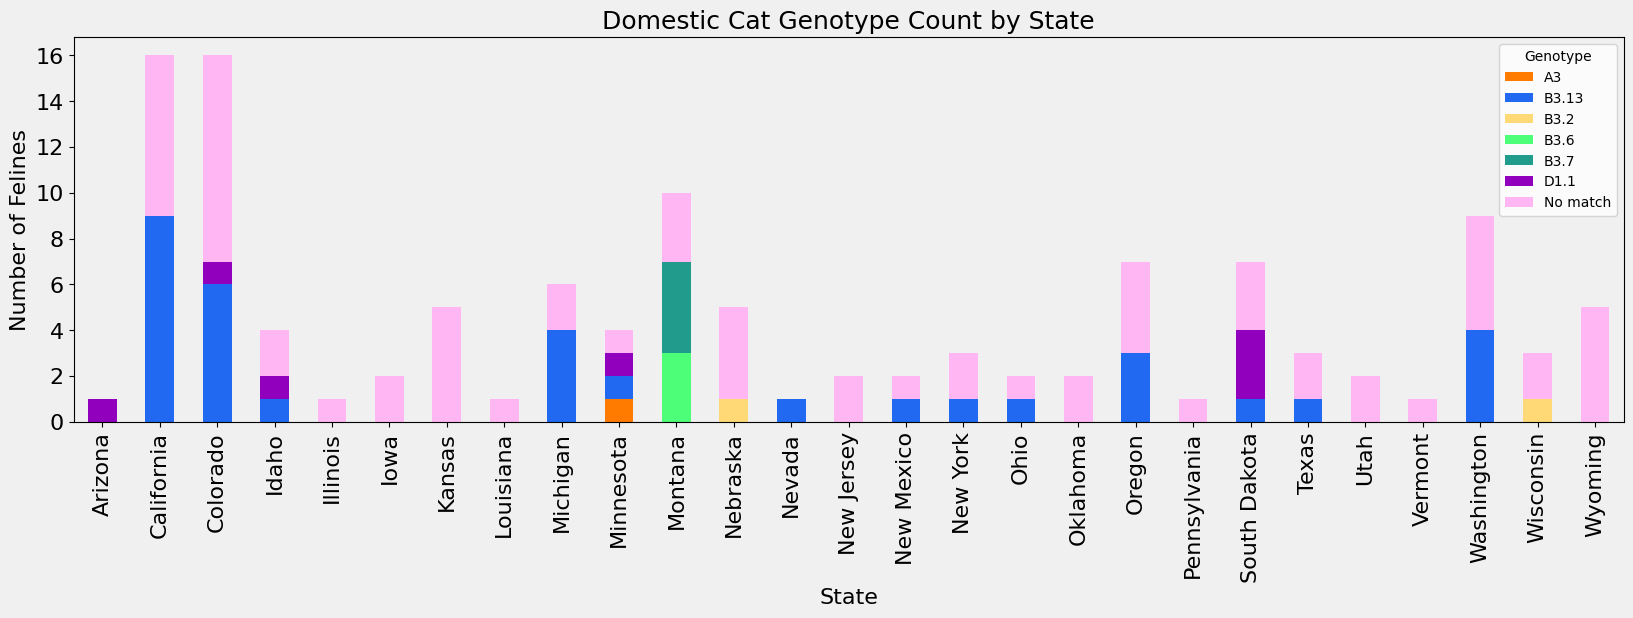

In [13]:
# Map plots
# By state in the US, bubble plot number of detections in each state 
# (such that the bubble is bigger with more detections)

os.chdir(cat_files + "USDA/")

consensus = pd.read_csv("USDA_feline_detections_08-05_2025_ambig_dates_consensus.csv")
consensus_original = pd.read_csv("USDA_feline_detections_08-05_2025_ambig_dates_consensus.csv")
counties = pd.read_csv("uscounties.csv")
# counties["County"] = counties["county"]
consensus["County_State"] = consensus["County"].apply(lambda x: ''.join([i for i in x if not i.isdigit()])) + consensus["State"]
counties["County_State"] = counties["county_ascii"] + counties["state_name"]

# print(consensus["County_State"])

# consensus = consensus[consensus["Genotype"] != "No match"]
genotype_map = {"No match" : "#ffb6f3", "A3" : "#ff7b00", "B3.2" : "#fed976", "B3.6" : "#4cfe78", "B3.7" : "#219c8c", "B3.13" : "#2069f0", "D1.1" : "#9100bd"}
consensus = consensus.sort_values(by="Genotype")
# consensus = consensus.drop_duplicates(subset="State", keep="first")
consensus = consensus[["State", "County", "County_State", "Date Collected", "Species", "Genotype"]].groupby(["State", "County_State", "Genotype"]).count().reset_index()
# consensus = pd.merge(consensus, states_ref)
consensus = pd.merge(consensus, counties, on="County_State") #, "Abbreviation"])
consensus_pivot = pd.pivot_table(consensus, index="State", values="Species", columns="Genotype", aggfunc="count", fill_value=0)
# consensus["Category"] = consensus["Genotype"].map(genotype_map) #"1 - 9" if x < 10 else "10 - 18" if 9 < x and x < 19 else "19 - 27" if 18 < x and x < 28 else "28+")
print(consensus_pivot)

print(consensus_pivot.sum())

fig, axes = pyplot.subplots(1, 1)

# consensus.plot(ax=axes, kind="bar", figsize=[20, 5], title="Domestic Cat Genotype Count by State", colormap="viridis")
consensus_pivot.plot(ax=axes, kind="bar", stacked=True, figsize=[20,5],  color=genotype_map, fontsize=16)
axes.set_title("Domestic Cat Genotype Count by State", fontsize=18)
axes.set_xlabel("State", fontsize=16)
axes.set_ylabel("Number of Felines", fontsize=16)
axes.set_facecolor("#f0f0f0")
fig.patch.set_facecolor("#f0f0f0")

fig.savefig("cat_counts_state_genotype_usda_08-05-2025_v2.png", bbox_inches="tight")

In [14]:
import plotly.express as px
import plotly


# limits = np.linspace(consensus["Species_x"].min(), consensus["Species_x"].max(), 5)
# limits = [str(l) for l in limits]
# limits = [(limits[0], limits[1]), (limits[1], limits[2]), (limits[2], limits[3]), (limits[3], limits[4])]
# print(limits)

fig = go.Figure()

for i, genotype in enumerate(list(genotype_map.keys())):
    fig.add_trace(go.Scattergeo(
        name=genotype,
        locationmode = "USA-states",
        lon = consensus[consensus["Genotype"] == genotype]["lng"],
        lat = consensus[consensus["Genotype"] == genotype]["lat"],
        hoverinfo="text",
        hovertext = consensus[consensus["Genotype"] == genotype]["county_full"].apply(lambda x: x + ", " + str(consensus[consensus["Genotype"] == genotype].loc[consensus['county_full'] == x, 'Species'].iloc[0]) + " sample(s) of genotype " + genotype + " detected" if genotype != "No match" else x + ", " + str(consensus[consensus["Genotype"] == genotype].loc[consensus['county_full'] == x, 'Species'].iloc[0]) + " sample(s) of unknown genotype detected"),
        showlegend=True,
        marker_color=genotype_map[genotype],
        marker = dict(
            size = consensus[consensus["Genotype"] == genotype]["Species"]*30,
            # color = genotype_map[genotype],
            sizemode = "area"
        )))
    fig.update_layout(
        
        title_text = "USDA Feline Avian Influenza Detections",
        legend = {"itemsizing": "trace"},
        geo = dict(
            scope = 'usa',
            landcolor = 'rgb(200, 200, 200)'
        )
    )

# for lim in list(set(consensus["Category"])):
# fig.add_trace(go.Scattergeo(
#     locationmode = 'USA-states',
#     lon = consensus['Longitude'],
#     lat = consensus['Latitude'],
    
#     hoverinfo="text",
#     hovertext = consensus["Species_x"].apply(lambda x: str(x) + " detections"),
#     # showlegend=True,
#     marker = dict(
#         size = consensus['Species_x']*30,
#         color = consensus["Genotype"].map(genotype_map),
#         colorbar = dict(title="Genotype"), #, tickmode="array", tickvals=list(genotype_map.keys()), ticktext=list(genotype_map.keys())),
#         sizemode = 'area'
#     )
#     # marker_coloraxis="coloraxis3",
    
#      ))

# fig.update_layout(
#         title_text = 'USDA Feline Avian Influenza Detections',
#         # showlegend = True,
#         legend= {'itemsizing': 'trace'},
#         coloraxis_showscale=True,
#         geo = dict(
#             scope = 'usa' # ,
#             landcolor = 'rgb(217, 217, 217)',
#         )
#     )

fig.show()

plotly.offline.plot(fig, filename='C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/Feline_Avian_Influenza_Detections_08_05_2025_USDA_ambig_dates_v2.html')

'C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/Feline_Avian_Influenza_Detections_08_05_2025_USDA_ambig_dates_v2.html'

In [15]:
os.chdir(cat_files)

transmissions = pd.read_excel("Cat_Table.xlsx")
transmissions["Accession"] = transmissions["Other accessions (SRA or GISAID)"]

# print(transmissions)
# print(consensus)



consensus_original["Accession"] = consensus_original["Header"].fillna("none").apply(lambda x: x.split("|")[0] if x != "none" else x)

transmission_consensus = consensus_original.merge(transmissions, on="Accession", how="left")

print(transmission_consensus)

transmission_consensus["County_State"] = transmission_consensus["County"].apply(lambda x: ''.join([i for i in x if not i.isdigit()])) + transmission_consensus["State_x"]
counties["County_State"] = counties["county_ascii"] + counties["state_name"]

transmission_consensus = transmission_consensus[["State_x", "County", "County_State", "Date Collected_x", "Species", "Inferred source of infection", "Genotype_x"]].groupby(["State_x", "County_State", "Genotype_x", "Inferred source of infection"]).count().reset_index()
# consensus = pd.merge(consensus, states_ref)
transmission_consensus = pd.merge(transmission_consensus, counties, on="County_State") #, "Abbreviation"])

choropleth_list = ["CA", "NV", "ID", "UT", "AZ", "WY", "CO", "NM", "SD", "NE", "KS", "OK", "TX", "MN", "IA", "MI", "OH", "NC"]

choropleth_dict = {}
for state in choropleth_list:
    choropleth_dict[state] = 1

     Identifier_x       State_x     County Date Collected_x Date Detected  \
0               9        Oregon  Multnomah         7/1/2025      7/8/2025   
1              12    New Jersey     Mercer        6/30/2025      7/3/2025   
2              18    California    Alameda       12/11/2024     6/16/2025   
3              18    California    Alameda       12/11/2024     6/16/2025   
4              24  South Dakota     Aurora         5/6/2025     5/15/2025   
..            ...           ...        ...              ...           ...   
233           530        Oregon       Linn       12/27/2022      1/3/2023   
234           531        Oregon       Linn       12/19/2022    12/23/2022   
235           558      New York    Albany1        9/17/2022     9/27/2022   
236           612     Wisconsin    Lincoln        4/24/2022     5/24/2022   
237           613     Wisconsin    Lincoln         5/5/2022     5/24/2022   

    HPAI Strain       Species  Identifier_y  \
0       EA H5N1  domestic ca

In [24]:
fig = go.Figure()

source_map = {"dairy cattle raw milk":"#ff0000", "poultry-sourced raw pet food":"#0400ff", "wild birds":"#ffff00"}

for i, source in enumerate(list(source_map.keys())):
    print(source)

    

    fig.add_trace(go.Scattergeo(
        name=source,
        locationmode = "USA-states",
        lon = transmission_consensus[transmission_consensus["Genotype_x"] == "B3.13"][transmission_consensus["Inferred source of infection"] == source]["lng"],
        lat = transmission_consensus[transmission_consensus["Genotype_x"] == "B3.13"][transmission_consensus["Inferred source of infection"] == source]["lat"],
        # hoverinfo="text",
        # hovertext = transmission_consensus[transmission_consensus["Genotype_x"] == "B3.13"][transmission_consensus["Inferred source of infection"] == source]["county_full"].apply(lambda x: x + ", " + str(transmission_consensus[transmission_consensus["Genotype_x"] == "B3.13"][transmission_consensus["Inferred source of infection"] == source].loc[transmission_consensus['county_full'] == x, 'Species'].iloc[0]) + " B3.13 sample(s) of source " + source + " detected"),
        showlegend=True,
        marker_color=source_map[source],
        marker = dict(
            size = transmission_consensus[transmission_consensus["Genotype_x"] == "B3.13"][transmission_consensus["Inferred source of infection"] == source]["Species"]*30,
            color = source_map[source],
            sizemode = "area"
        )))
    

# Add choropleth layer for highlighting
fig.add_trace(go.Choropleth(
    name="has known infected dairy cattle",
    locations=choropleth_list,
    z=list(choropleth_dict.values()),
    locationmode='USA-states',
    colorscale=[[0, 'lightgrey'], [1, 'yellow']], # Color for highlighted states
    showscale=False,
    marker_line_color='darkgrey',
    showlegend=True
))

fig.update_layout(
    
    title_text = "USDA Feline B3.13 Avian Influenza Detections by Inferred Source of Infection",
    legend=dict(
        x=0.75,  # Horizontal center
        y=1  # Vertical center
    ),
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(200, 200, 200)'
    )
)

fig.show()

plotly.offline.plot(fig, filename='C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/Feline_Avian_Influenza_Detections_08_05_2025_B3_13_infection_source_vlegend.html')

dairy cattle raw milk
poultry-sourced raw pet food
wild birds


C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\4169843976.py:13: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\4169843976.py:14: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\4169843976.py:20: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\4169843976.py:13: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\4169843976.py:14: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\1\ipykernel_23228\4169843976.py:20: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

C:\Users\maksiaevai.NCBI_NT\AppDat

'C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/Feline_Avian_Influenza_Detections_08_05_2025_B3_13_infection_source_vlegend.html'